# 1. Exploratory Data Analysis (EDA)

### EDA

In this step, we import the main libraries used for data analysis:
- Pandas is used to load and manipulate the dataset.
- NumPy helps with numerical operations.
- Matplotlib and Seaborn are used to create visualizations.

After importing the libraries, we load the training dataset using pd.read_csv().
The head() function displays the first few rows of the dataset so we can quickly verify that the data was loaded correctly and see the structure of the features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("train_carbreakdown.csv")

# Preview first rows
df.head()

,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,494744.972722,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
2,1304,Hyundai,1.0,188558.432414,6678.958321,11726.320455,25.491428,41.692205,medium,hybrid,47.223966,5.842726,winter,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
4,47,NaN,10.0,118366.394287,4222.193011,12551.181627,65.766074,47.159242,low,diesel,77.368891,6.724967,winter,0


The shape function tells us how many rows and columns are present in the dataset.
- Rows represent individual vehicles
- Columns represent features describing each vehicle

The info() function gives more detailed information about the dataset:
-  Data types of each column (numerical or categorical)
- Number of non-missing values
- Memory usage

This helps us determine which features may require preprocessing later.

In [2]:
# Check dataset dimensions
df.shape

# Inspect data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         1050 non-null   int64  
 1   vehicle_brand              1029 non-null   object 
 2   vehicle_age_years          1034 non-null   float64
 3   mileage_km                 1033 non-null   float64
 4   engine_hours               1035 non-null   float64
 5   last_service_km_ago        1040 non-null   float64
 6   oil_quality_pct            1014 non-null   float64
 7   avg_trip_length_km         1038 non-null   float64
 8   weather_exposure           1037 non-null   object 
 9   fuel_type                  1036 non-null   object 
 10  cleanliness_score          995 non-null    float64
 11  driver_satisfaction_score  1037 non-null   float64
 12  tyre_type                  1033 non-null   object 
 13  breakdown_next_30_days     1050 non-null   int64

Missing data can negatively affect machine learning models.
The isnull().sum() function counts how many missing values exist in each column.

If missing values are found, we will later handle them using imputation techniques, such as replacing them with the median for numerical features or the most frequent category for categorical features.

In [3]:
# Count missing values per column
df.isnull().sum()

id                            0
vehicle_brand                21
vehicle_age_years            16
mileage_km                   17
engine_hours                 15
last_service_km_ago          10
oil_quality_pct              36
avg_trip_length_km           12
weather_exposure             13
fuel_type                    14
cleanliness_score            55
driver_satisfaction_score    13
tyre_type                    17
breakdown_next_30_days        0
dtype: int64

The target variable in this project is breakdown_next_30_days, which indicates whether a car will break down within the next 30 days.
- 0 → No breakdown expected
- 1 → Breakdown expected

The value_counts() function shows how many observations belong to each class.

Using normalize=True converts these counts into percentages, allowing us to see whether the dataset is balanced or imbalanced.
Class imbalance can affect model performance and may require special handling during training.

In [4]:
# Count occurrences of each class
df['breakdown_next_30_days'].value_counts()

# Percentage distribution of classes
df['breakdown_next_30_days'].value_counts(normalize=True)

breakdown_next_30_days
0    0.832381
1    0.167619
Name: proportion, dtype: float64

The describe() function provides statistical summaries for numerical variables, including:
- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles (25%, 50%, 75%)

This helps us understand the typical range of each feature and detect unusual values.

In [5]:
df.describe()

,id,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,cleanliness_score,driver_satisfaction_score,breakdown_next_30_days
count,1050.000000,1034.000000,1.033000e+03,1035.000000,1040.000000,1014.000000,1038.000000,995.000000,1037.000000,1050.000000
mean,742.984762,9.399420,3.639119e+06,4368.929467,10681.075986,60.682779,38.861387,69.393768,6.972183,0.167619
std,430.089010,5.752228,2.585818e+07,2214.510223,9341.969609,20.298624,47.968702,15.570872,1.478278,0.373706
min,0.000000,0.000000,-1.829042e+02,-50.000000,10.869020,0.000000,1.011100,-13.171570,2.504369,0.000000
25%,372.250000,5.000000,8.338616e+04,2773.353090,3374.773323,47.377582,8.187057,58.902723,6.001099,0.000000
50%,740.500000,9.000000,1.202357e+05,3967.125562,8085.318122,60.528422,16.788852,69.504547,6.928004,0.000000
75%,1109.250000,14.000000,1.674871e+05,5432.498224,14455.318280,74.654436,44.308719,79.597898,8.022503,0.000000
max,1498.000000,20.000000,3.734539e+08,10298.582128,40592.195120,102.548055,201.015553,144.139920,10.291940,1.000000


Histograms allow us to visualize the distribution of numerical variables.

This helps us identify:
- Skewed distributions
- Extreme values
- Possible outliers
- Differences in feature ranges

Understanding feature distributions is important when preparing data for machine learning models.

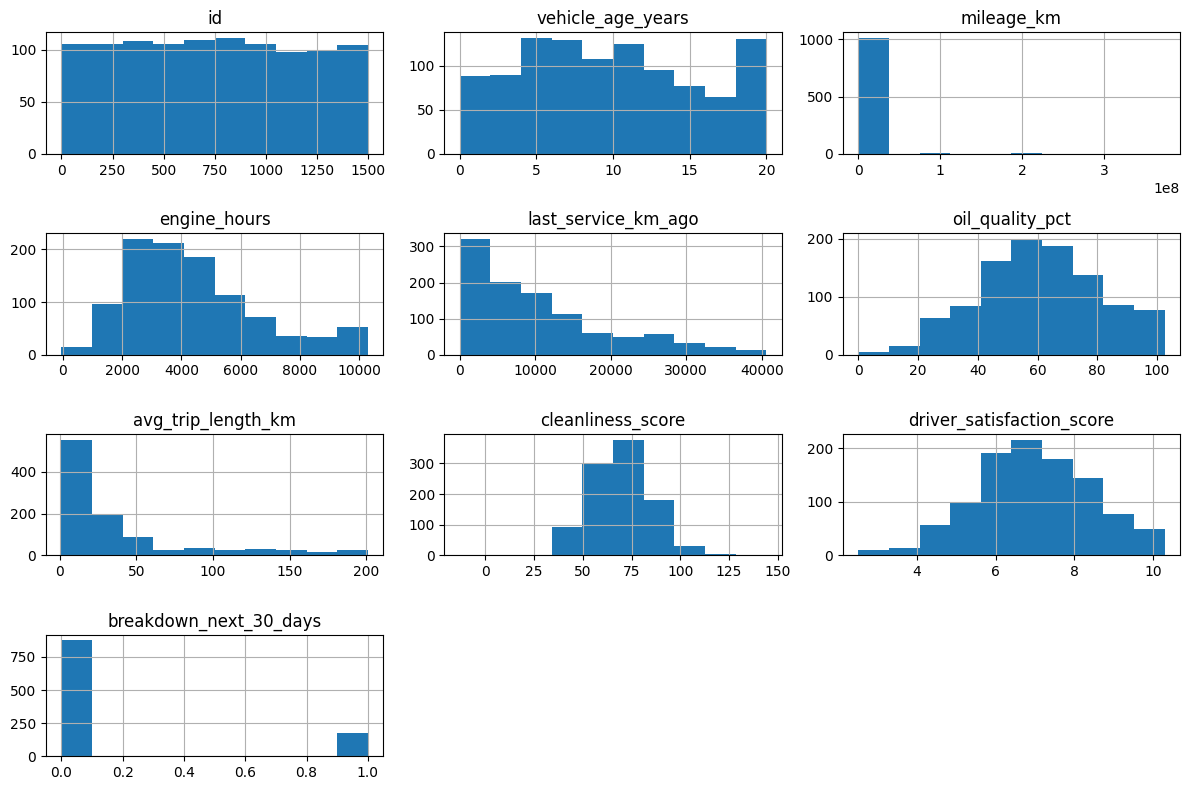

In [6]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

Boxplots are used to identify outliers in numerical features.
Outliers appear as points outside the whiskers of the boxplot and represent values that are much higher or lower than most observations.
In vehicle data, outliers may occur due to:
- Extremely high mileage
- Unusual engine usage
- Rare maintenance conditions

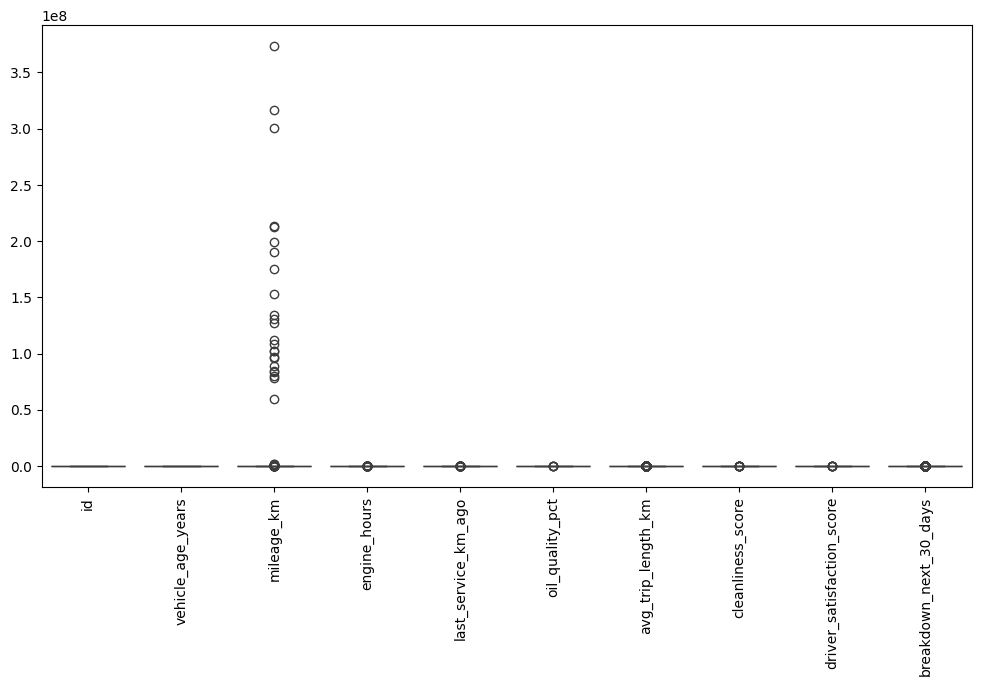

In [7]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()

This analysis examines the distribution of the fuel_type variable.

The value_counts() function shows how many vehicles belong to each fuel category.
The countplot() visualization makes it easier to compare the frequencies visually.

Understanding categorical distributions helps determine whether certain categories dominate the dataset.

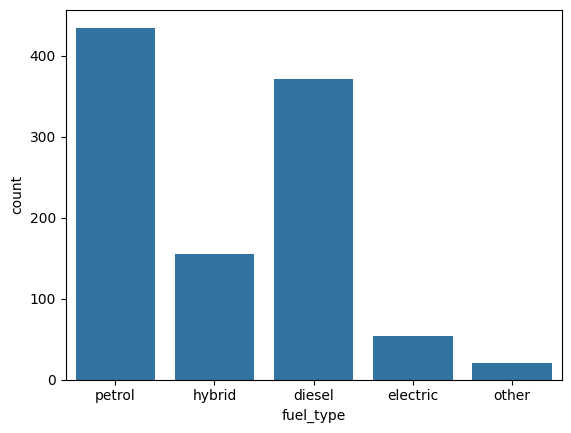

In [8]:
df['fuel_type'].value_counts()

sns.countplot(x='fuel_type', data=df)
plt.show()

This analysis investigates whether vehicles with higher mileage are more likely to break down.

The boxplot compares the mileage distribution for vehicles that break down versus those that do not.

The groupby() function calculates the average mileage for each class, helping us determine if mileage is an important predictor of breakdown risk.

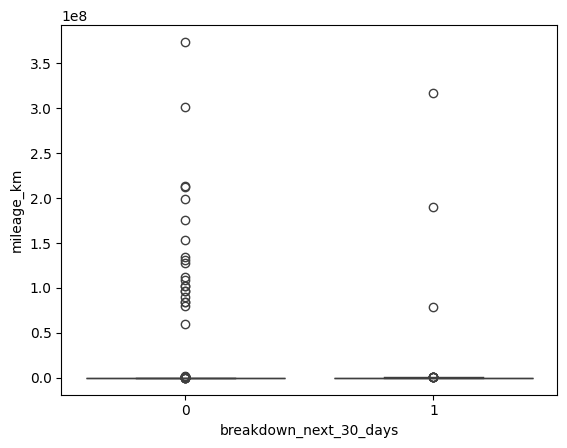

breakdown_next_30_days
0    3.674587e+06
1    3.466412e+06
Name: mileage_km, dtype: float64

In [9]:
sns.boxplot(x='breakdown_next_30_days', y='mileage_km', data=df)
plt.show()

df.groupby('breakdown_next_30_days')['mileage_km'].mean()

Here we explore whether breakdown probability varies by fuel type.

The crosstab() table calculates the proportion of breakdowns within each fuel category.
The bar plot visualizes the average breakdown rate per fuel type, which may reveal patterns related to engine technology or vehicle usage.

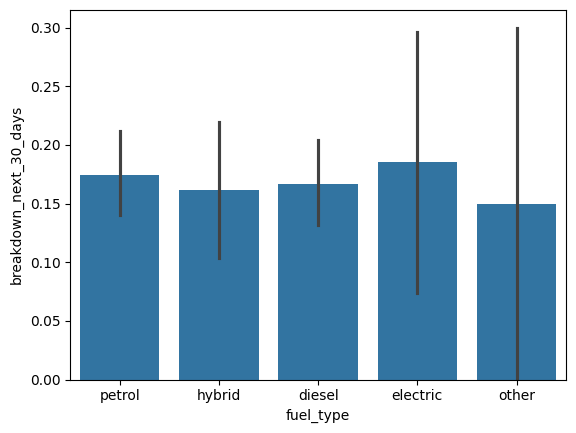

In [10]:
pd.crosstab(df['fuel_type'], df['breakdown_next_30_days'], normalize='index')

sns.barplot(x='fuel_type', y='breakdown_next_30_days', data=df)
plt.show()

Correlation analysis helps identify relationships between numerical features.

The heatmap displays correlation values between variables:
- Values close to 1 or -1 indicate strong relationships
- Values close to 0 indicate weak relationships

This analysis helps detect:
- Features that may influence breakdown risk
- Variables that are strongly related to each other (multicollinearity)

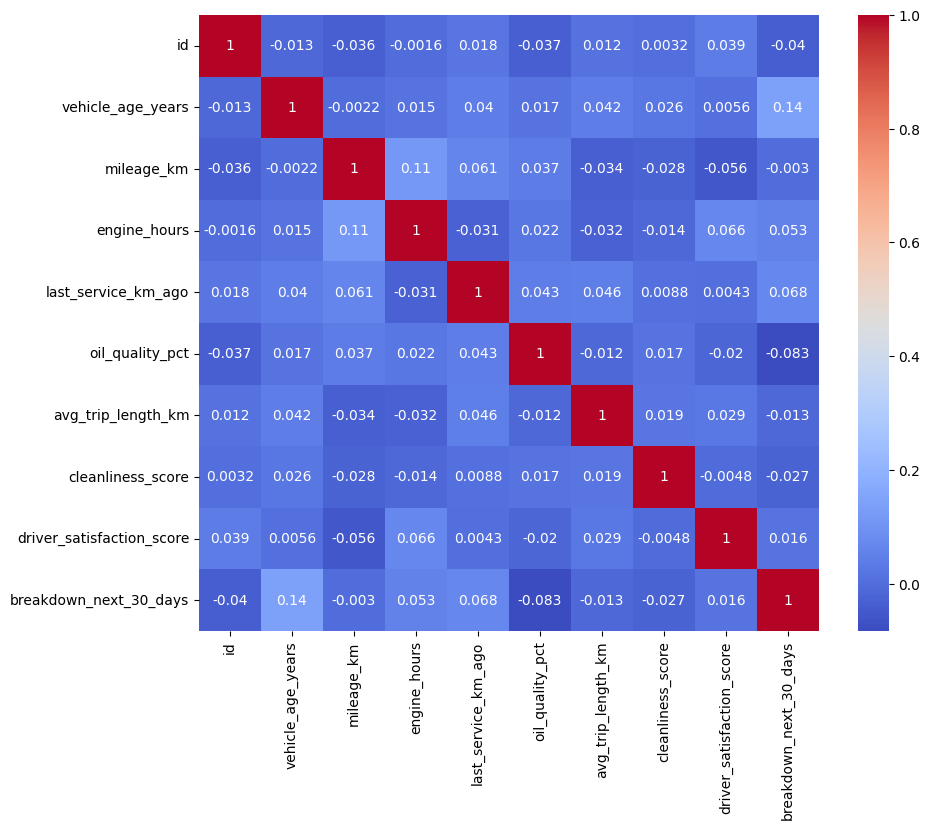

In [11]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# 2. Modeling Pipeline

These libraries are part of Scikit-learn, which is used for building machine learning models.

Main components:
- train_test_split

   Splits the dataset into training and validation sets.
- ColumnTransformer

   Applies different preprocessing steps to different types of features.
- Pipeline

   Combines preprocessing and modeling steps into a single workflow.

- SimpleImputer

   Handles missing values in the dataset.

- OneHotEncoder

   Converts categorical variables into numerical format so the model can process them.

- RandomForestClassifier

   A machine learning algorithm that builds multiple decision trees and combines them to make predictions.

- Evaluation metrics
   - accuracy_score
   - confusion_matrix
   - classification_report

These help measure how well the model performs.

In [12]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Machine learning models require a clear separation between:
- Features (X) → Input variables used for prediction
- Target (y) → The variable we want to predict

In this case:
- X contains vehicle information (mileage, oil quality, fuel type, etc.)
- y contains the breakdown indicator (0 or 1)

In [13]:
TARGET = "breakdown_next_30_days"

y = df[TARGET]
X = df.drop(columns=[TARGET])

The dataset is divided into:
- Training set (80%) → used to train the model
- Validation set (20%) → used to evaluate model performance

The parameter stratify=y ensures that the proportion of breakdowns (0 and 1) remains the same in both sets.

The random_state ensures reproducibility so that the split remains consistent every time the code runs.

In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Different types of variables require different preprocessing methods.

This step automatically separates the dataset into:

Numerical features, such as:
- mileage_km
- engine_hours
- oil_quality_pct
- vehicle_age_years

Categorical features, such as:
- vehicle_brand
- fuel_type
- tyre_type
- weather_exposure

Handling them separately improves model performance.

In [15]:
num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(exclude="number").columns

Preprocessing ensures the data is clean and usable for machine learning.

For numerical variables:
- Missing values are replaced with the median value.
- The median is preferred because it is less sensitive to extreme values.

For categorical variables:
- Missing values are replaced with the most frequent category
- The categorical variables are converted into numbers using One-Hot Encoding

One-Hot Encoding creates binary columns representing each category.

Example:

fuel_type

fuel_type	petrol	diesel	hybrid
petrol	1	0	0

The parameter handle_unknown="ignore" ensures the model does not crash if new categories appear in the test set.

In [16]:
numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

The ColumnTransformer applies the appropriate preprocessing to each type of feature:
- Numerical columns → median imputation
- Categorical columns → most frequent imputation + one-hot encoding

This ensures that each feature is transformed correctly before entering the model.

In [17]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

## 3 Random Forest model as a baseline 
#### (one or more additional modeling approaches)

### Model Initialization

The Random Forest model is initialized with several hyperparameters that influence how the model learns from the data.

- **n_estimators = 800** specifies the number of decision trees in the forest.
- **class_weight = "balanced"** helps address potential class imbalance by assigning higher importance to the minority class.
- **max_features = "sqrt"** allows each tree to consider a random subset of features when splitting nodes, which improves diversity among trees.
- **min_samples_leaf = 2** prevents the trees from becoming too complex and helps reduce overfitting.
- **random_state = 42** ensures reproducibility of results.

In [18]:
rf = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
    class_weight="balanced",
    max_features="sqrt",
    min_samples_leaf=2,
    n_jobs=-1
)

### Building the Modeling Pipeline

A pipeline is used to combine the preprocessing steps and the machine learning model into a single workflow.

The preprocessing stage handles tasks such as:
- imputing missing values
- encoding categorical variables

By integrating preprocessing and modeling into one pipeline, we ensure that the same transformations are applied consistently during training and prediction. This also prevents data leakage.

In [19]:
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf)
])

### Training the Model

The model is trained using the training dataset. During this process, the Random Forest algorithm builds multiple decision trees based on different random samples of the data.

Each tree learns patterns in the dataset that help distinguish between vehicles that are likely to break down and those that are not.

In [20]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

### Generating Predictions

Once the model has been trained, it can be used to predict whether vehicles in the validation dataset are likely to experience a breakdown within the next 30 days.

In [21]:
y_pred = model.predict(X_val)

### Model Evaluation

To evaluate the performance of the Random Forest model, several metrics are used:

- **Accuracy** measures the proportion of correct predictions.
- **Confusion Matrix** provides insight into the types of errors the model makes.
- **Classification Report** includes precision, recall, and F1-score.

These metrics help determine how effectively the model distinguishes between vehicles that will break down and those that will not.

In [22]:
accuracy = accuracy_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)

print("Validation Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_val, y_pred))

Validation Accuracy: 0.8333333333333334
Confusion Matrix:
 [[175   0]
 [ 35   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91       175
           1       0.00      0.00      0.00        35

    accuracy                           0.83       210
   macro avg       0.42      0.50      0.45       210
weighted avg       0.69      0.83      0.76       210



C:\Users\ellen\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ellen\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ellen\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

### Confusion Matrix Visualization

A visual representation of the confusion matrix helps interpret the performance of the classification model.

The matrix shows:
- **True Positives:** correctly predicted breakdowns
- **True Negatives:** correctly predicted non-breakdowns
- **False Positives:** predicted breakdowns that did not occur
- **False Negatives:** missed breakdown predictions

This visualization helps identify potential weaknesses in the model.

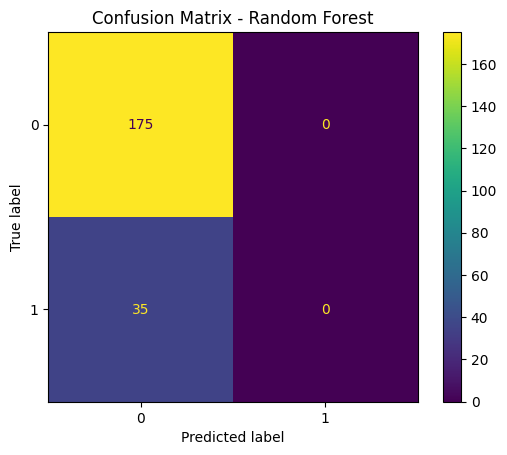

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
plt.title("Confusion Matrix - Random Forest")
plt.show()

# 4. Proper Evaluation of Each Model
### (including a confusion matrix)

### Decision Tree Visualization

A Random Forest model consists of many individual decision trees. To better understand how the model makes predictions, one tree from the forest is visualized.

Each node represents a decision rule based on a feature value. The branches represent possible outcomes of these decisions, eventually leading to a predicted class.

Although the Random Forest contains hundreds of trees, visualizing a single tree provides insight into how the model evaluates vehicle features when predicting breakdown risk.

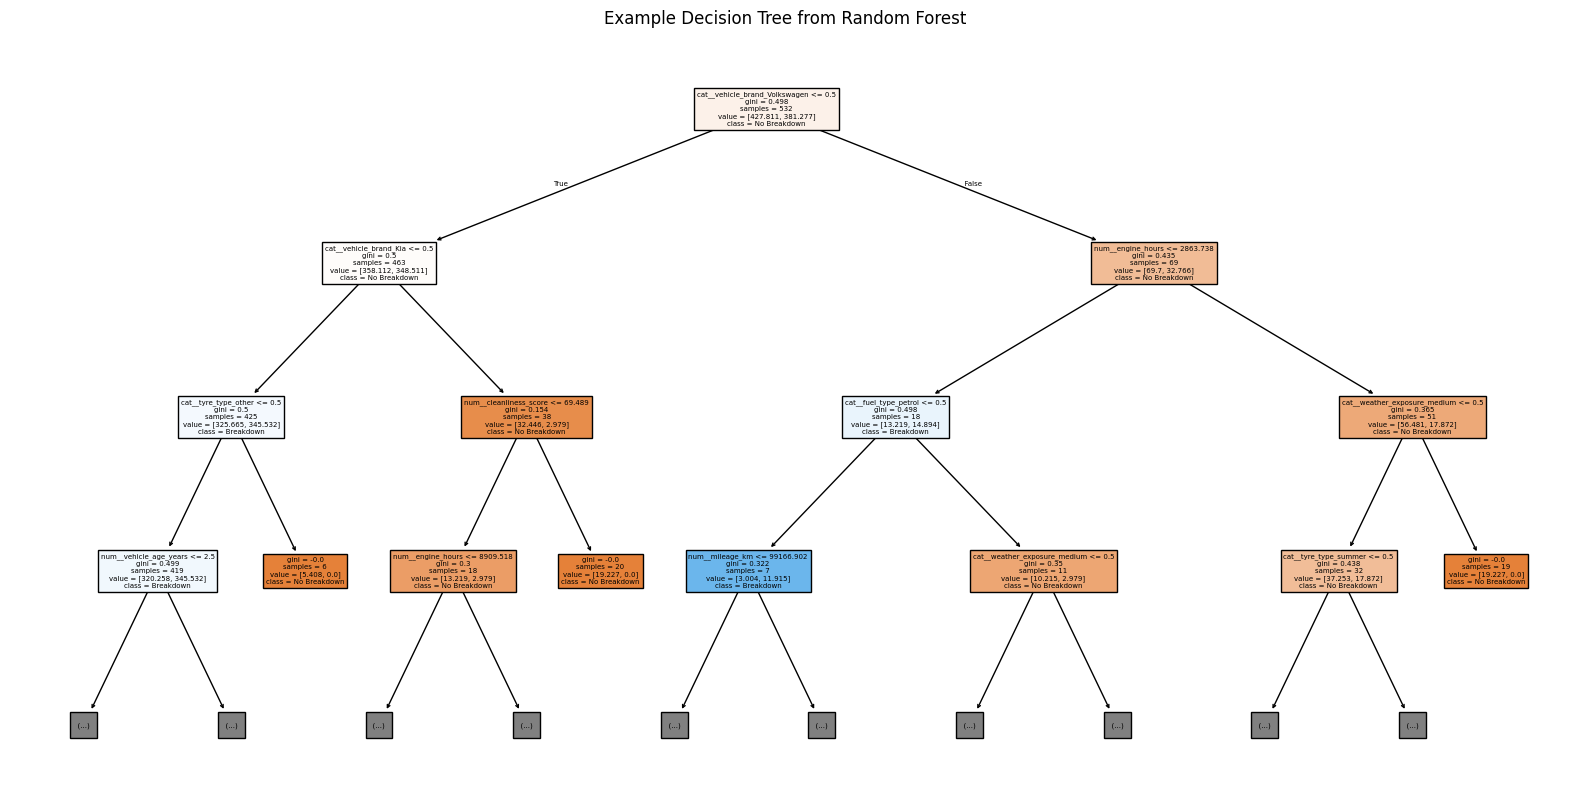

In [24]:
from sklearn.tree import plot_tree

rf_model = model.named_steps["model"]
feature_names = model.named_steps["preprocess"].get_feature_names_out()

tree = rf_model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["No Breakdown","Breakdown"],
    filled=True,
    max_depth=3
)

plt.title("Example Decision Tree from Random Forest")
plt.show()

### Feature Importance Analysis

Random Forest models provide a measure of feature importance, which indicates how much each feature contributes to the prediction.

Features with higher importance scores play a larger role in determining whether a vehicle is predicted to break down.

This analysis helps identify which vehicle characteristics have the strongest influence on mechanical failure risk.

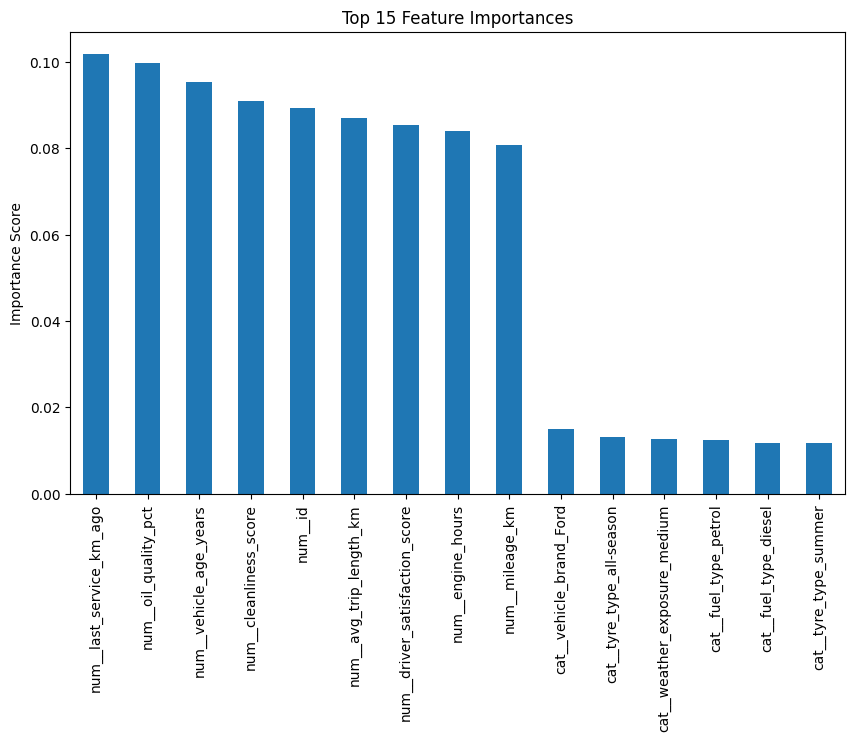

In [25]:
importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind="bar")
plt.title("Top 15 Feature Importances")
plt.ylabel("Importance Score")
plt.show()

### ROC Curve

The ROC curve evaluates the ability of the model to distinguish between the two classes.

It plots the True Positive Rate against the False Positive Rate at different classification thresholds.

The **Area Under the Curve (AUC)** summarizes the overall performance of the model. A higher AUC value indicates better classification performance.

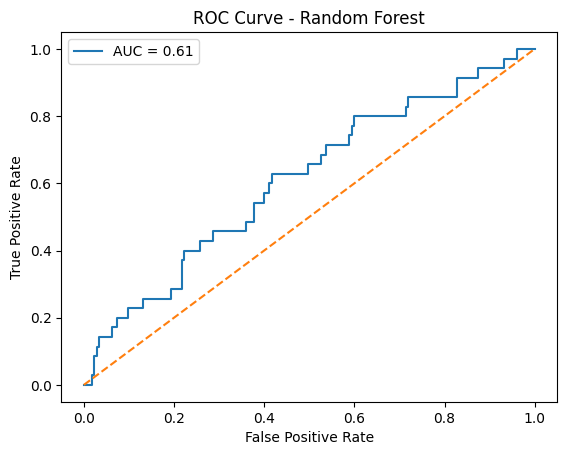

In [26]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_val)[:,1]

fpr, tpr, thresholds = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

# 5. GenAI Section